In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds

# Standard map

In [2]:
u = np.array([0.2, 0.5])
k = 1.5
N = int(1e5)
sample_times = np.array(np.unique(
    np.logspace(np.log10(1), np.log10(N), 1000).astype(int)
), dtype=np.int64)
time = np.arange(1, N + 1)
np.random.seed(0)

In [3]:
ds = dds(model="standard map")
ds.set_parameters(k)

In [4]:
exponents = ds.lyapunov(u, 10, return_history=True)

In [5]:
%%time
exponents = ds.lyapunov(u, N, return_history=True)
exponents2 = ds.lyapunov(u, N)
exponents[-1, :], exponents2

CPU times: user 75.6 ms, sys: 1.8 ms, total: 77.4 ms
Wall time: 82.2 ms


(array([ 0.25173585, -0.25173585]), array([ 0.25173585, -0.25173585]))

In [6]:
%%time
exponents2 = ds.lyapunov(u, N, return_history=True, sample_times=sample_times)

CPU times: user 36.4 ms, sys: 641 μs, total: 37.1 ms
Wall time: 39.6 ms


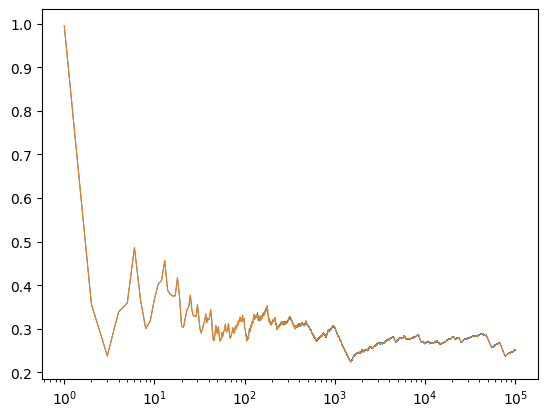

In [7]:
plt.plot(time, exponents[:, 0], lw=0.75)
plt.plot(sample_times, exponents2[:, 0], lw=0.75)
plt.xscale("log")

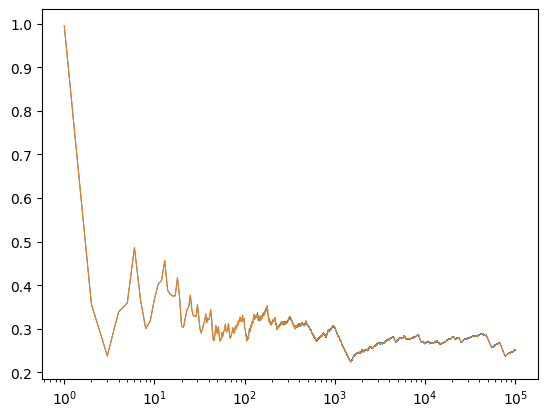

In [8]:
plt.plot(time, exponents[:, 0], lw=0.75)
plt.plot(sample_times, exponents2[:, 0], lw=0.75)
plt.xscale("log")

# 4D symplectic map

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds

# Define the symplectic map
ds = dds(model="4d symplectic map")

In [10]:
u = [3.0, 0, 0.5, 0]
eps1 = 0.5
eps2 = 0.1
xi = 0.001
parameters = [eps1, eps2, xi]
ds.set_parameters(parameters)

N = int(1e6)
sample_times = np.array(np.unique(
    np.logspace(np.log10(1), np.log10(N), 1000).astype(int)
), dtype=np.int64)
time = np.arange(1, N + 1)
np.random.seed(0)
lyapunov_exponents = ds.lyapunov(u, 10, return_history=True)

In [11]:
%%time
lyapunov_exponents = ds.lyapunov(u, N, return_history=True)

CPU times: user 3.56 s, sys: 30.2 ms, total: 3.59 s
Wall time: 3.61 s


In [12]:
%%time
lyapunov_exponents2 = ds.lyapunov(u, N, return_history=True, sample_times=sample_times)

CPU times: user 3.47 s, sys: 26.8 ms, total: 3.5 s
Wall time: 3.52 s


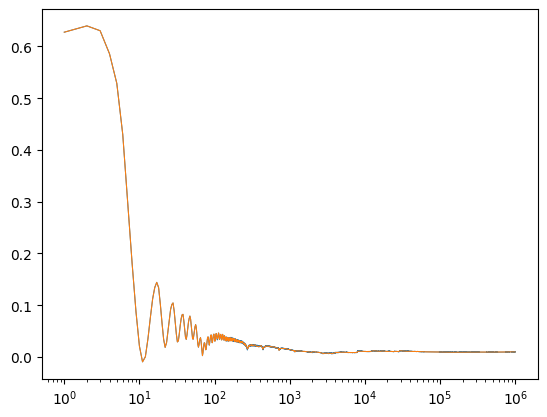

In [13]:
plt.plot(time, lyapunov_exponents[:, 0], lw=0.75)
plt.plot(sample_times, lyapunov_exponents2[:, 0], lw=0.75)
plt.xscale("log")

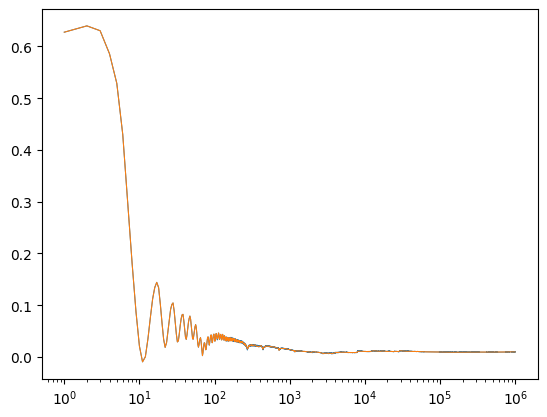

In [14]:
plt.plot(time, lyapunov_exponents[:, 0], lw=0.75)
plt.plot(sample_times, lyapunov_exponents2[:, 0], lw=0.75)
plt.xscale("log")